In [1]:
# ## Cell 1: Import Libraries

# Import required libraries
import requests
from bs4 import BeautifulSoup
import re
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# ## Cell 2: Define the Fetch Function

def fetch_flipkart_products(url):
  
    # Set User-Agent to mimic a regular browser (helps prevent blocking)
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36',
        'Accept-Language': 'en-US,en;q=0.9',
    }
    
    try:
        # Make the HTTP request
        response = requests.get(url, headers=headers, timeout=30)
        response.raise_for_status()  # Raise an exception for HTTP errors
        
        # Return the HTML content
        return response.text
        
    except requests.exceptions.RequestException as e:
        print(f"Error fetching the URL: {e}")
        return None



In [3]:
# ## Cell 3: Define the Parse Function - Parse Flipkart product listing HTML to extract product details

def parse_flipkart_products(html_content):
   
    soup = BeautifulSoup(html_content, 'html.parser')
    products = []
    
    # Look for product containers - these are div elements with data-id attribute
    product_divs = soup.find_all('div', attrs={'data-id': True})
    
    print(f"Found {len(product_divs)} product containers")
    
    for product_div in product_divs:
        product_info = {}
        
        # Extract product name
        name_element = product_div.find('a', class_='s1WHx6')
        if not name_element:
            name_element = product_div.find('a', class_='IRpwTa')
        if not name_element:
            name_element = product_div.find('a', class_='wjcEIp')
        if name_element:
            product_info['Product Name'] = name_element.text.strip()
        
        # Extract current price
        current_price_element = product_div.find('div', class_='_30jeq3')
        if not current_price_element:
            current_price_element = product_div.find('div', class_='Nx9bqj')
        if current_price_element:
            # Remove currency symbol and commas
            price_text = current_price_element.text.strip()
            price_text = re.sub(r'[^\d]', '', price_text)
            product_info['Current Price'] = price_text
        
        # Extract original price (if available)
        original_price_element = product_div.find('div', class_='_3I9_wc')
        if not original_price_element:
            original_price_element = product_div.find('div', class_='yRaY8j')
        if original_price_element:
            # Remove currency symbol and commas
            price_text = original_price_element.text.strip()
            price_text = re.sub(r'[^\d]', '', price_text)
            product_info['Original Price'] = price_text
        
        # Extract discount
        discount_element = product_div.find('div', class_='_3Ay6Sb')
        if not discount_element:
            discount_element = product_div.find('div', class_='UkUFwK')
        if discount_element:
            product_info['Discount'] = discount_element.text.strip()
        
        # Extract rating
        rating_element = product_div.find('div', class_='_3LWZlK')
        if not rating_element:
            rating_element = product_div.find('div', class_='XQDdHH')
        if rating_element:
            # Get only the text part without the star icon
            try:
                rating_text = rating_element.contents[0]
                if rating_text:
                    product_info['Rating'] = str(rating_text).strip()
            except:
                product_info['Rating'] = rating_element.text.strip()
        
        # Extract number of ratings
        rating_count_element = product_div.find('span', class_='_2_R_DZ')
        if not rating_count_element:
            rating_count_element = product_div.find('span', class_='Wphh3N')
        if rating_count_element:
            # Remove parentheses and clean up
            count_text = rating_count_element.text.strip()
            count_text = re.sub(r'[^\d,]', '', count_text)
            product_info['Number of Ratings'] = count_text
        
        # Extract availability info
        availability_element = product_div.find('div', class_='yiggsN O5Fpg8')
        if availability_element:
            product_info['Availability'] = availability_element.text.strip()
        
        # Extract delivery info
        delivery_element = product_div.find('div', {'style': 'color:#000000;font-size:12px;font-weight:400'})
        if not delivery_element:
            delivery_element = product_div.find('div', class_='_2Tpdn3')
        if delivery_element:
            product_info['Delivery Info'] = delivery_element.text.strip()
        
        # Get product URL
        url_element = product_div.find('a', class_='VJA3rP')
        if not url_element:
            url_element = product_div.find('a', class_='_1fQZEK')
        if not url_element:
            url_element = product_div.find('a', class_='s1Q9rs')
        if url_element and 'href' in url_element.attrs:
            url_path = url_element['href']
            # Make relative URLs absolute
            if url_path.startswith('/'):
                product_info['URL'] = f"https://www.flipkart.com{url_path}"
            else:
                product_info['URL'] = url_path
        
        # Get product image URL
        img_element = product_div.find('img', class_='DByuf4')
        if not img_element:
            img_element = product_div.find('img', class_='_396cs4')
        if img_element and 'src' in img_element.attrs:
            product_info['Image URL'] = img_element['src']
            
        products.append(product_info)
    
    return products


In [4]:
# ## Cell 4: Fetch the HTML Content

# Define the URL
url = "https://www.flipkart.com/search?q=airpods+pro+2&sid=0pm%2Cfcn%2C821%2Fa7x%2C2si&as=on&as-show=on&otracker=AS_QueryStore_OrganicAutoSuggest_2_7_na_na_na&otracker1=AS_QueryStore_OrganicAutoSuggest_2_7_na_na_na&as-pos=2&as-type=RECENT&suggestionId=airpods+pro+2%7CTrue+Wireless&requestId=a86b47b2-225d-415c-a573-1751f7aca0d7&as-searchtext=airpods"

# Fetch the HTML content
print("Fetching HTML content from Flipkart...")
html_content = fetch_flipkart_products(url)

# Check if the fetch was successful
if html_content:
    print(f"Successfully fetched HTML content! Length: {len(html_content)} characters")
    
    # Optional: Save the HTML to a file for debugging
    with open("flipkart_html.html", "w", encoding="utf-8") as f:
        f.write(html_content)
    print("HTML content saved to 'flipkart_html.html'")
else:
    print("Failed to fetch HTML content.")

Fetching HTML content from Flipkart...
Successfully fetched HTML content! Length: 591331 characters
HTML content saved to 'flipkart_html.html'


In [5]:
# ## Cell 5: Parse the HTML and Extract Product Information

if html_content:                                                   # Only run this code if the url returns
    print("Parsing HTML to extract product information...")
    products = parse_flipkart_products(html_content)
    
    # Display the number of products found
    print(f"Successfully extracted information for {len(products)} products!")
    
    # Preview the first product
    if products:                                                 # Only run this code if there are product tags
        print("\nFirst product details:")
        for key, value in products[0].items():
            print(f"{key}: {value}")


Parsing HTML to extract product information...
Found 40 product containers
Successfully extracted information for 40 products!

First product details:
Product Name: Apple AirPods Pro (2nd generation) with MagSafe Case (U...
Current Price: 19899
Original Price: 24900
Discount: 20% off
Rating: 4.6
Number of Ratings: 21,132
Availability: Only 2 left
Delivery Info: Free delivery
URL: https://www.flipkart.com/apple-airpods-pro-2nd-generation-magsafe-case-usb-c-bluetooth/p/itm60c8f5a308352?pid=ACCGTCYRNADXCXNG&lid=LSTACCGTCYRNADXCXNGWCU03Q&marketplace=FLIPKART&q=airpods+pro+2&store=0pm%2Ffcn%2F821%2Fa7x%2F2si&spotlightTagId=BestsellerId_0pm%2Ffcn%2F821%2Fa7x%2F2si&srno=s_1_1&otracker=AS_QueryStore_OrganicAutoSuggest_2_7_na_na_na&otracker1=AS_QueryStore_OrganicAutoSuggest_2_7_na_na_na&fm=organic&iid=036464d6-8c14-450a-b343-eaef89b8b4bd.ACCGTCYRNADXCXNG.SEARCH&ppt=None&ppn=None&ssid=dhywupzgg00000001741201367997&qH=2e78eeb888eeb94d
Image URL: https://rukminim2.flixcart.com/image/612/612/xif0q/

In [6]:

# ## Cell 6: Create a DataFrame and Analyze the Data

# Convert the list of product dictionaries to a DataFrame
if 'products' in locals() and products:
    df = pd.DataFrame(products)
    
    # Display information about the DataFrame
    print("DataFrame Information:")
    print(f"Shape: {df.shape}")
    print("\nColumns:", df.columns.tolist())
    
    # Display the first few rows
    print("\nPreview of the DataFrame:")
    print(df.head())
    
    # Basic statistics for numeric columns
    print("\nBasic statistics for prices:")
    numeric_cols = ['Current Price', 'Original Price']
    numeric_cols = [col for col in numeric_cols if col in df.columns]
    
    if numeric_cols:
        # Convert to numeric types first
        for col in numeric_cols:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        
        print(df[numeric_cols].describe())
    
    # Count of products by different categories
    if 'Rating' in df.columns:
        print("\nCount of products by rating:")
        print(df['Rating'].value_counts().sort_index(ascending=False))

DataFrame Information:
Shape: (40, 10)

Columns: ['Product Name', 'Current Price', 'Original Price', 'Discount', 'Rating', 'Number of Ratings', 'Availability', 'Delivery Info', 'URL', 'Image URL']

Preview of the DataFrame:
                                        Product Name Current Price  \
0  Apple AirPods Pro (2nd generation) with MagSaf...         19899   
1       BeatFlow 2nd GenMax AirPods Pro S2 Bluetooth          1201   
2  BeatFlow S1 AirPods Pro (2nd generation) with ...          1199   
3  Arrexure AirPods Pro (2nd Generation), Premium...          1963   
4  Arrexure AirPods Pro 2, Magnetic Wireless Char...          1999   

  Original Price Discount Rating Number of Ratings   Availability  \
0          24900  20% off    4.6            21,132    Only 2 left   
1           2499  51% off    NaN               NaN    Only 1 left   
2           2999  60% off    NaN               NaN    Only 1 left   
3           4999  60% off    NaN               NaN  Only few left   
4         

/Users/Scott/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


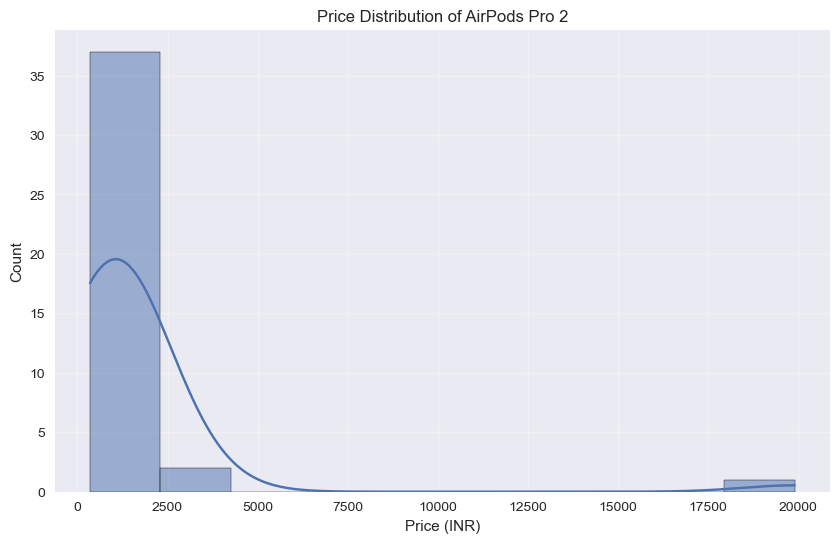

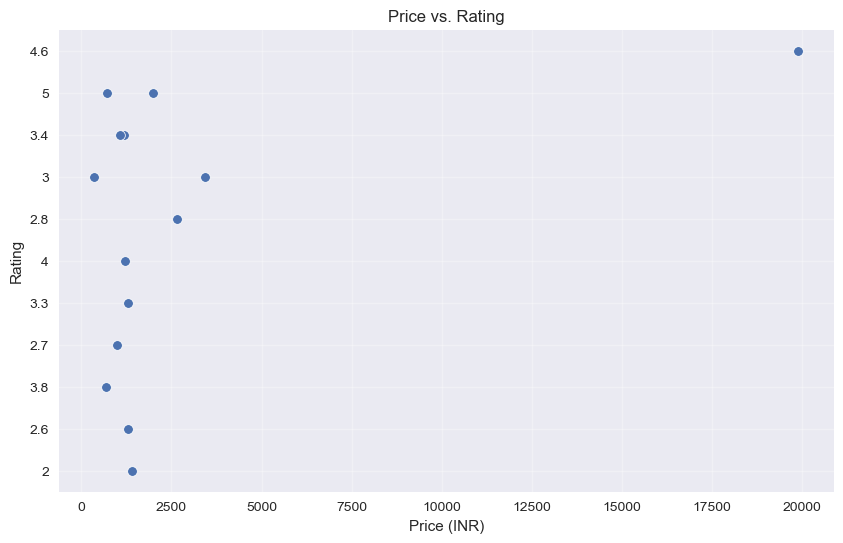

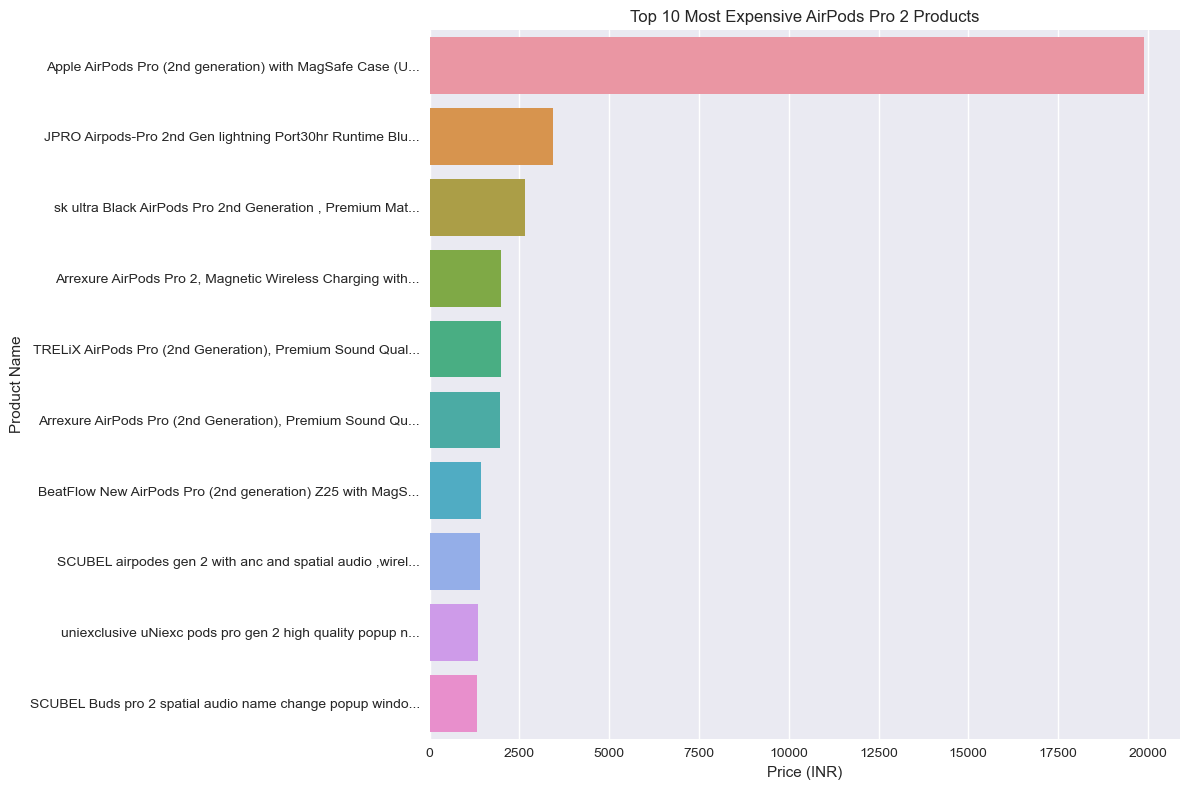

In [7]:
# ## Cell 8: Visualize the Data (Optional)

# Optional: Create some visualizations of the data
if 'df' in locals() and len(df) > 0:
    # Set the style
    plt.style.use('seaborn-v0_8')
    
    # Price distribution
    if 'Current Price' in df.columns:
        plt.figure(figsize=(10, 6))
        sns.histplot(df['Current Price'].astype(float), bins=10, kde=True)
        plt.title('Price Distribution of AirPods Pro 2')
        plt.xlabel('Price (INR)')
        plt.ylabel('Count')
        plt.grid(True, alpha=0.3)
        plt.show()
    
    # Price vs. Rating
    if 'Current Price' in df.columns and 'Rating' in df.columns:
        plt.figure(figsize=(10, 6))
        sns.scatterplot(x='Current Price', y='Rating', data=df)
        plt.title('Price vs. Rating')
        plt.xlabel('Price (INR)')
        plt.ylabel('Rating')
        plt.grid(True, alpha=0.3)
        plt.show()
    
    # Top 10 products by price
    if 'Product Name' in df.columns and 'Current Price' in df.columns:
        plt.figure(figsize=(12, 8))
        top_10 = df.sort_values('Current Price', ascending=False).head(10)
        sns.barplot(x='Current Price', y='Product Name', data=top_10)
        plt.title('Top 10 Most Expensive AirPods Pro 2 Products')
        plt.xlabel('Price (INR)')
        plt.tight_layout()
        plt.show()
